#OMNIPLANT AI

This is project is about predicting plant disease using images through deep learnig technques.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The dataset is in the form of zip file. So, it has to be extracted from there.

In [ ]:
import zipfile
import os

zip_path = "/content/drive/My Drive/Colab Notebooks/plant_village_.zip"
extract_path = "/content/plantvillage dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Here, it showed the folder inside the zip file which are color, segmented and greyscale as dataset is already organized into three categories.

In [ ]:
import os

# Check what's inside the "plantvillage dataset" folder
print(os.listdir("/content/plantvillage dataset/plantvillage dataset"))

['color', 'grayscale', 'segmented']


In [ ]:
dataset_path = "/content/plantvillage dataset/plantvillage dataset"
color_path = os.path.join(dataset_path, "color")
grayscale_path = os.path.join(dataset_path, "grayscale")
segmented_path = os.path.join(dataset_path, "segmented")

print("Corrected dataset path:", dataset_path)
print("Folders inside:", os.listdir(dataset_path))


Corrected dataset path: /content/plantvillage dataset/plantvillage dataset
Folders inside: ['color', 'grayscale', 'segmented']


In [ ]:
import shutil

source = "/content/plantvillage dataset/plantvillage dataset"
destination = "/content/plantvillage dataset"

# Move all files and folders
for item in os.listdir(source):
    shutil.move(os.path.join(source, item), destination)

# Remove the extra folder
os.rmdir(source)

print("Dataset structure fixed!")
print(os.listdir("/content/plantvillage dataset"))

Dataset structure fixed!
['color', 'grayscale', 'segmented']


check the dataset structure below

In [ ]:
import os

dataset_path = "/content/plantvillage dataset"

# List the main folders inside the dataset
print("Dataset folders:", os.listdir(dataset_path))

# Check inside 'color' folder (or any category folder)
color_path = os.path.join(dataset_path, "color")
if os.path.exists(color_path):
    print("Categories in 'color':", os.listdir(color_path))


Dataset folders: ['color', 'grayscale', 'segmented']
Categories in 'color': ['Cherry_(including_sour)___healthy', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Strawberry___healthy', 'Apple___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Potato___Early_blight', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Early_blight', 'Apple___Cedar_apple_rust', 'Grape___Black_rot', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Potato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Corn_(maize)___healthy', 'Tomato___Bacterial_spot', 'Corn_(maize)___Common_rust_', 'Grape___healthy', 'Apple___Black_rot', 'Peach___Bacterial_spot', 'Tomato___Late_blight', 'Potato___healthy', 'Pepper,_bell___healthy', 'Grape___Esca_(Black_Measles)', 'Cherry_(including_sour)___Powdery_mildew', 'Blueberry___healthy', 'Pepper,_bell___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Spider_mites Two-spotted_sp

Dataset has already greyscale images. so i'll just check if all the greyscale images are in proper format.

In [ ]:
import cv2
import os
import numpy as np

# Define the path to the grayscale images
grayscale_path = "/content/plantvillage dataset/grayscale"

# List to store any non-grayscale images found
non_grayscale_images = []

# Iterate through categories (subfolders)
for category in os.listdir(grayscale_path):
    category_path = os.path.join(grayscale_path, category)

    # Check if it's a directory
    if not os.path.isdir(category_path):
        continue

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Error loading image: {img_path}")
            continue

        # Check if the image is grayscale by verifying single-channel or equal RGB values
        if len(img.shape) == 3 and not np.all(img[..., 0] == img[..., 1]) and not np.all(img[..., 1] == img[..., 2]):
            non_grayscale_images.append(img_path)

print("Verification complete!")
if non_grayscale_images:
    print(f"Warning: Found {len(non_grayscale_images)} non-grayscale images.")
    for img in non_grayscale_images:
        print(img)
else:
    print("All images are properly in grayscale format.")


Verification complete!
All images are properly in grayscale format.


show images

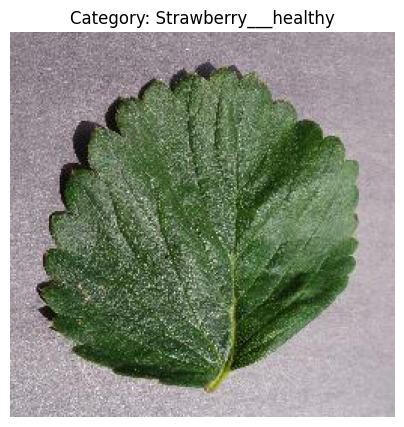

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

# Define dataset path
dataset_path = "/content/plantvillage dataset"
color_path = os.path.join(dataset_path, "color")

# Pick a random category (disease type)
categories = os.listdir(color_path)
random_category = random.choice(categories)
category_path = os.path.join(color_path, random_category)

# Pick a random image from that category
random_image = random.choice(os.listdir(category_path))
image_path = os.path.join(category_path, random_image)

# Load and display the image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR (OpenCV) to RGB (Matplotlib)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()


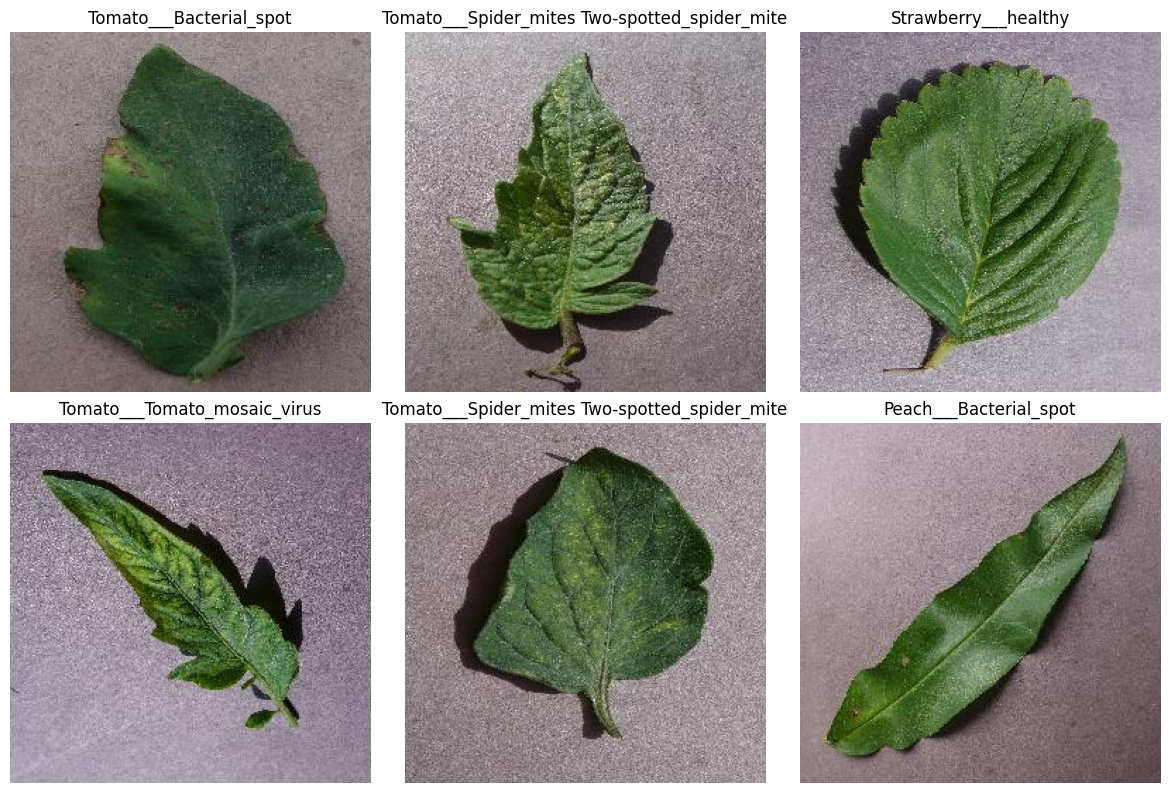

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows, 3 columns

for ax in axes.flat:
    random_category = random.choice(categories)
    category_path = os.path.join(color_path, random_category)
    random_image = random.choice(os.listdir(category_path))
    image_path = os.path.join(category_path, random_image)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(random_category)
    ax.axis("off")

plt.tight_layout()
plt.show()


Above some random images of the dataset is shown.

#Resize

In [ ]:
image_size = (128, 128)

def resize_images(source_dir, target_dir):
    os.makedirs(target_dir, exist_ok=True)

    for category in os.listdir(source_dir):
        os.makedirs(os.path.join(target_dir, category), exist_ok=True)

        for img_name in os.listdir(os.path.join(source_dir, category)):
            img = cv2.imread(os.path.join(source_dir, category, img_name))
            img = cv2.resize(img, image_size)
            cv2.imwrite(os.path.join(target_dir, category, img_name), img)

resize_images(color_path, "/content/plantvillage dataset/color_resized")
resize_images(grayscale_path, "/content/plantvillage dataset/grayscale_resized")

print("Images resized successfully!")


Images resized successfully!


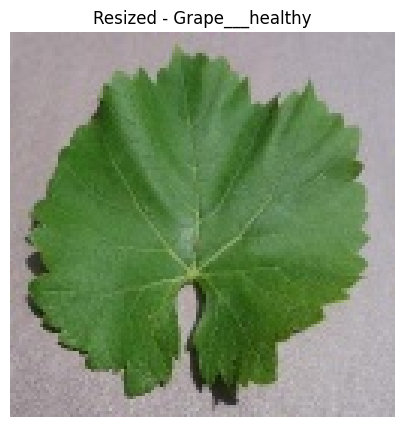

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

# Define resized dataset path
resized_path = "/content/plantvillage dataset/color_resized"

# Pick a random category (disease type)
categories = os.listdir(resized_path)
random_category = random.choice(categories)
category_path = os.path.join(resized_path, random_category)

# Pick a random image from that category
random_image = random.choice(os.listdir(category_path))
image_path = os.path.join(category_path, random_image)

# Load and display the image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Resized - {random_category}")
plt.axis("off")
plt.show()


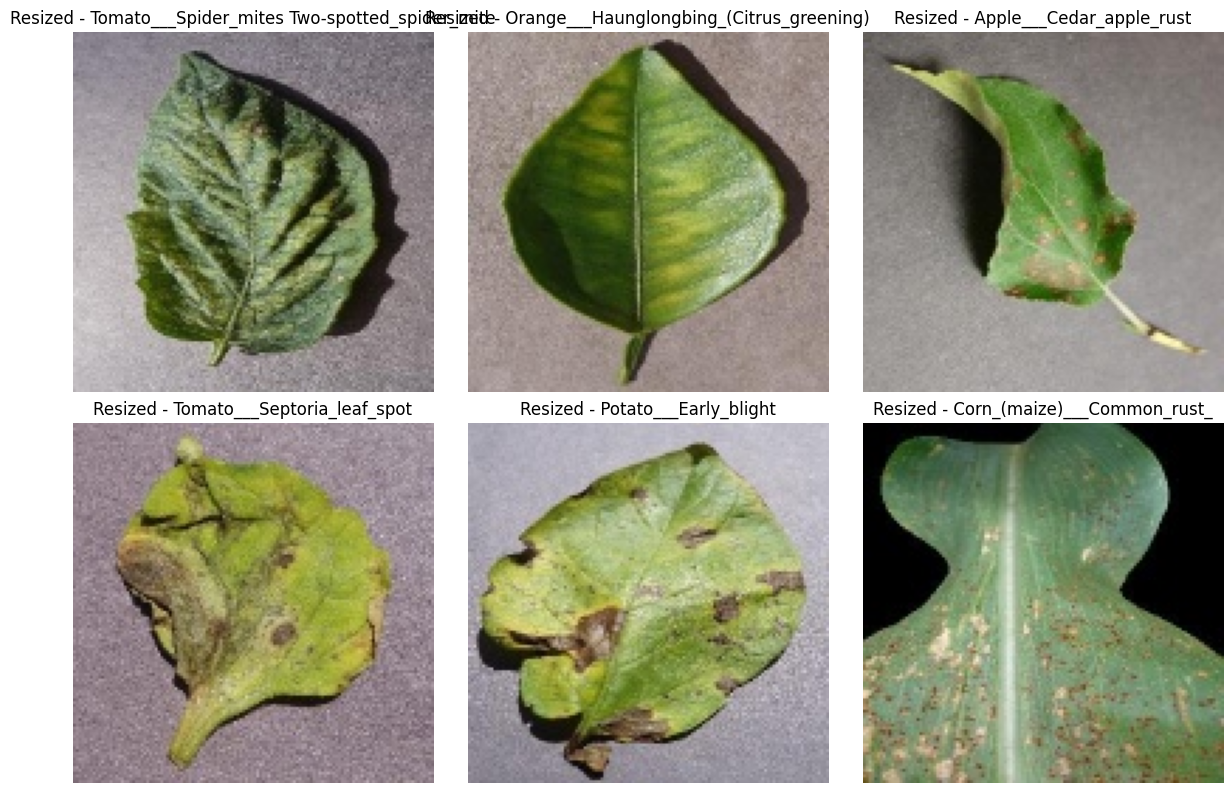

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows, 3 columns

for ax in axes.flat:
    random_category = random.choice(categories)
    category_path = os.path.join(resized_path, random_category)
    random_image = random.choice(os.listdir(category_path))
    image_path = os.path.join(category_path, random_image)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(f"Resized - {random_category}")
    ax.axis("off")

plt.tight_layout()
plt.show()


#Splitting the data into traing and test

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
dataset_path = "/content/plantvillage dataset/color_resized"
train_path = "/content/plantvillage dataset/train"
test_path = "/content/plantvillage dataset/test"

# Create directories for train and test sets
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Loop through categories and split images
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    train_category_path = os.path.join(train_path, category)
    test_category_path = os.path.join(test_path, category)

    os.makedirs(train_category_path, exist_ok=True)
    os.makedirs(test_category_path, exist_ok=True)

    # Get all image paths in the category
    image_paths = [os.path.join(category_path, img) for img in os.listdir(category_path)]

    # Split the dataset (80% train, 20% test)
    train_files, test_files = train_test_split(image_paths, test_size=0.2, random_state=42)

    # Move images to the respective directories
    for train_file in train_files:
        shutil.move(train_file, os.path.join(train_category_path, os.path.basename(train_file)))
    for test_file in test_files:
        shutil.move(test_file, os.path.join(test_category_path, os.path.basename(test_file)))

print("Dataset split into training and testing sets successfully!")


Dataset split into training and testing sets successfully!


In [ ]:
import shutil
from google.colab import files

# Zip the test directory
shutil.make_archive("/content/test_dataset", 'zip', "/content/plantvillage dataset/test")

# Download the zip file
files.download("/content/test_dataset.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#real augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# No augmentation for test set, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training and testing data
train_generator = train_datagen.flow_from_directory(
    "/content/plantvillage dataset/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    "/content/plantvillage dataset/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

print("Real-Time Augmentation Ready!")


Found 43429 images belonging to 38 classes.
Found 10876 images belonging to 38 classes.
Real-Time Augmentation Ready!


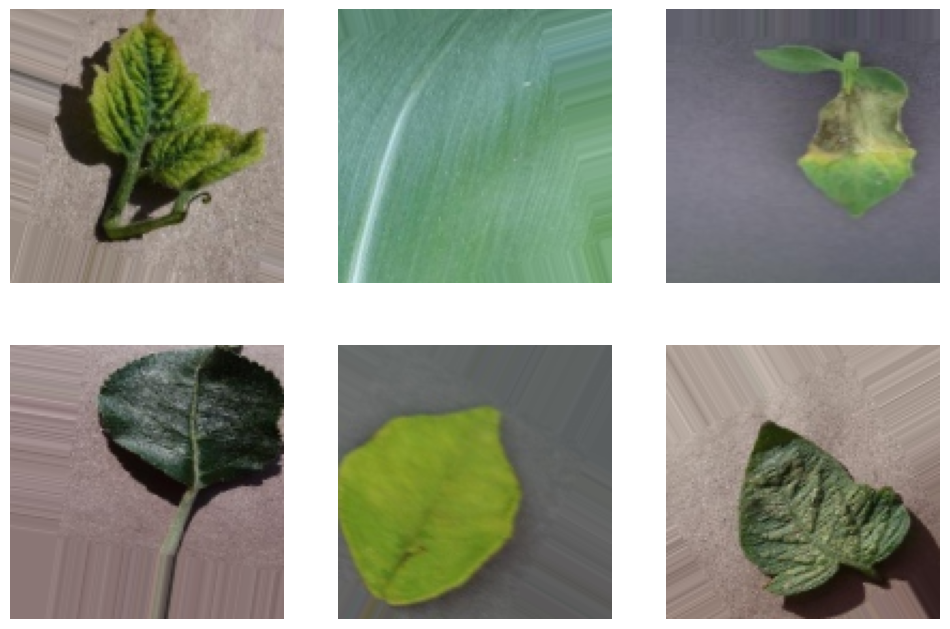

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images
images, labels = next(train_generator)

# Show 6 augmented images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis("off")

plt.show()


#vgg16 model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths for the dataset
train_path = "/content/plantvillage dataset/train"
test_path = "/content/plantvillage dataset/test"

# Data generators for training and validation
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading training and testing data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

# Get the number of classes from the training generator
num_classes = train_generator.num_classes

# Load the pretrained VGG16 model WITHOUT the top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the convolutional base
for layer in base_model.layers:
    layer.trainable = False  # Prevent training the base model

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Better than Flatten() for reducing parameters
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer for classification
output_layer = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Found 43429 images belonging to 38 classes.
Found 10876 images belonging to 38 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,118,438 (57.67 MB)

 Trainable params: 403,750 (1.54 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# compile the model

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_generator, epochs=20, validation_data=test_generator)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 64s 40ms/step - accuracy: 0.2713 - loss: 2.8456 - val_accuracy: 0.6587 - val_loss: 1.2907
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.6011 - loss: 1.3918 - val_accuracy: 0.7666 - val_loss: 0.8423
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6924 - loss: 1.0185 - val_accuracy: 0.8034 - val_loss: 0.6667
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7378 - loss: 0.8438 - val_accuracy: 0.8321 - val_loss: 0.5667
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7696 - loss: 0.7297 - val_accuracy: 0.8489 - val_loss: 0.5025
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7910 - loss: 0.6633 - val_accuracy: 0.8602 - val_loss: 0.4597
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8013 - loss: 0.6123 - val_accuracy: 0.8620 - val_loss: 0.4336
Epoch 8/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8172 - loss: 0.57

In [ ]:
# Save the model
model.save('/content/drive/My Drive/Colab Notebooks/vgg_16_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [ ]:
# Save the model
model.save('/content/drive/My Drive/Colab Notebooks/vgg_16_model.keras')
print("Model saved successfully!")

Model saved successfully!


# load the model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Load the trained model
model = tf.keras.models.load_model('/content/drive/My Drive/Colab Notebooks/vgg_16_model.keras', compile=False)

# Recompile the model if necessary (optional)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


# use model to make predictions

In [ ]:
import os

# List all images in the test directory (example path)
test_images = os.listdir("/content/plantvillage dataset/test")

# Display a few image file names
print(test_images[:5])  # Display first 5 images


['Tomato___Tomato_mosaic_virus', 'Potato___Early_blight', 'Apple___Cedar_apple_rust', 'Potato___Late_blight', 'Blueberry___healthy']


the above code is to get the list of all the classed of the test dataset.

In [ ]:
import os

# Define the test directory
test_dir = "/content/plantvillage dataset/test"

# List all subdirectories (categories)
categories = os.listdir(test_dir)

# Loop through categories and list images
image_files = []
for category in categories:
    category_path = os.path.join(test_dir, category)

    # Ensure it's a directory and list all image files
    if os.path.isdir(category_path):
        for img_file in os.listdir(category_path):
            image_files.append(os.path.join(category_path, img_file))

# Display first few image file paths
print(image_files[:5])  # Display first 5 image paths


['/content/plantvillage dataset/test/Tomato___Tomato_mosaic_virus/a3bfb1c8-d60a-4894-adf8-297035279f47___PSU_CG 2306.JPG', '/content/plantvillage dataset/test/Tomato___Tomato_mosaic_virus/69d3740b-5aba-47e2-ae2f-46541333c3a5___PSU_CG 2420.JPG', '/content/plantvillage dataset/test/Tomato___Tomato_mosaic_virus/0f47e5f6-7271-45c8-8364-e962dedd83c9___PSU_CG 2148.JPG', '/content/plantvillage dataset/test/Tomato___Tomato_mosaic_virus/c16ac093-9b9b-4c37-b669-aa68f3cd55cf___PSU_CG 2270.JPG', '/content/plantvillage dataset/test/Tomato___Tomato_mosaic_virus/67d62cc2-ac5e-4ad7-91a0-c097163df653___PSU_CG 2048.JPG']


In [ ]:

import numpy as np
import os
import random
from tensorflow.keras.preprocessing import image

# Define the path to the test dataset
test_path = "/content/plantvillage dataset/test"

# Get a random class folder from the test dataset
class_folders = os.listdir(test_path)
random_class = random.choice(class_folders)  # Pick a random class
class_path = os.path.join(test_path, random_class)

# Get a random image file from the selected class
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not image_files:
    print("No images found in the selected test class folder.")
else:
    img_path = os.path.join(class_path, random.choice(image_files))  # Pick a random image
    print(f"🔍 Selected Image: {img_path}")

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(128, 128))  # Resize to match model input
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize to [0,1] range

    # Make a prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)

    # Get class labels from the training generator
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]

    print(f"✅ Predicted Disease: {predicted_label}")



🔍 Selected Image: /content/plantvillage dataset/test/Tomato___Septoria_leaf_spot/4f35adfa-03b3-4562-b970-19548dda84d1___Matt.S_CG 2457.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
✅ Predicted Disease: Tomato___Septoria_leaf_spot


# evaluate on entire test set

In [ ]:
# Evaluate the model on the test set using the test generator
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


340/340 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9195 - loss: 0.2513
✅ Test Loss: 0.2467
✅ Test Accuracy: 92.16%


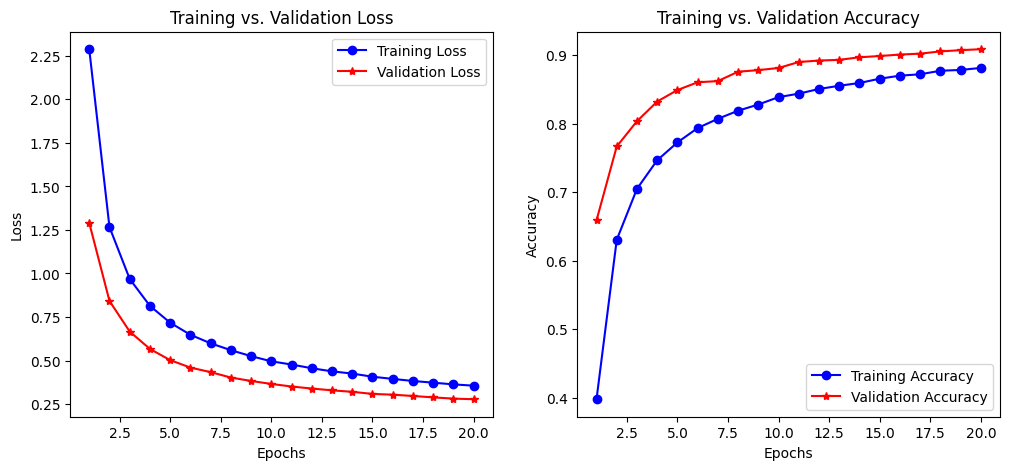

In [ ]:
import matplotlib.pyplot as plt

# Extract loss and accuracy values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

# Plot Training vs. Validation Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # First subplot (1 row, 2 columns, 1st plot)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Plot Training vs. Validation Accuracy
plt.subplot(1, 2, 2)  # Second subplot (1 row, 2 columns, 2nd plot)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()

plt.show()


#predictions

In [ ]:
import numpy as np

# Get predictions (returns probabilities for each class)
predictions = model.predict(test_generator)

# Get confidence scores (max probability per sample)
confidence_scores = np.max(predictions, axis=1)

# Get predicted class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get true labels
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())  # Class names


340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step


In [ ]:
for i in range(10):  # Show first 10 predictions
    print(f"Actual: {class_names[true_labels[i]]}, "
          f"Predicted: {class_names[predicted_labels[i]]}, "
          f"Confidence: {confidence_scores[i] * 100:.2f}%")


Actual: Apple___Apple_scab, Predicted: Tomato___Spider_mites Two-spotted_spider_mite, Confidence: 87.10%
Actual: Apple___Apple_scab, Predicted: Grape___Black_rot, Confidence: 61.59%
Actual: Apple___Apple_scab, Predicted: Strawberry___Leaf_scorch, Confidence: 99.98%
Actual: Apple___Apple_scab, Predicted: Cherry_(including_sour)___healthy, Confidence: 99.97%
Actual: Apple___Apple_scab, Predicted: Tomato___Late_blight, Confidence: 98.38%
Actual: Apple___Apple_scab, Predicted: Strawberry___healthy, Confidence: 98.46%
Actual: Apple___Apple_scab, Predicted: Potato___Early_blight, Confidence: 99.48%
Actual: Apple___Apple_scab, Predicted: Tomato___Leaf_Mold, Confidence: 83.72%
Actual: Apple___Apple_scab, Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus, Confidence: 95.31%
Actual: Apple___Apple_scab, Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus, Confidence: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


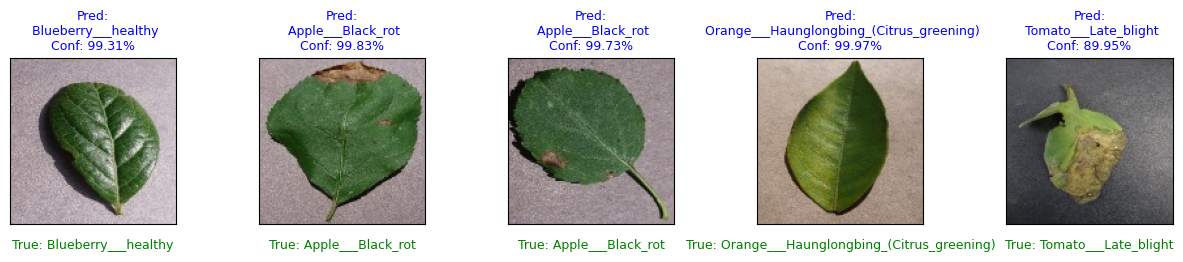

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get class labels (mapping indices to class names)
class_labels = list(train_generator.class_indices.keys())

# Pick a batch of images from the test generator
test_images, test_labels = next(test_generator)  # Get a batch

# Make predictions
predictions = model.predict(test_images)

# Get predicted classes
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)  # True class indices

# Get confidence scores (highest probability for each prediction)
confidence_scores = np.max(predictions, axis=1)

# Plot the first 5 images with predictions and confidence scores
fig, axes = plt.subplots(1, 5, figsize=(15, 6))  # Increased figure width

for i, ax in enumerate(axes):
    ax.imshow(test_images[i])  # Image is already normalized (0-1 range)
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks

    # Display predicted label and confidence score at the top
    ax.set_title(f"Pred:\n {class_labels[predicted_classes[i]]}\n"
                 f"Conf: {confidence_scores[i] * 100:.2f}%", fontsize=9, color='blue')

    # Display true label below the image using ax.text()
    ax.text(0.5, -0.15, f"True: {class_labels[true_classes[i]]}",
            fontsize=9, color='green', ha='center', transform=ax.transAxes)

plt.subplots_adjust(wspace=0.5)  # Add spacing between images to prevent overlap
plt.show()


#Visualize Model Predictions on Multiple Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


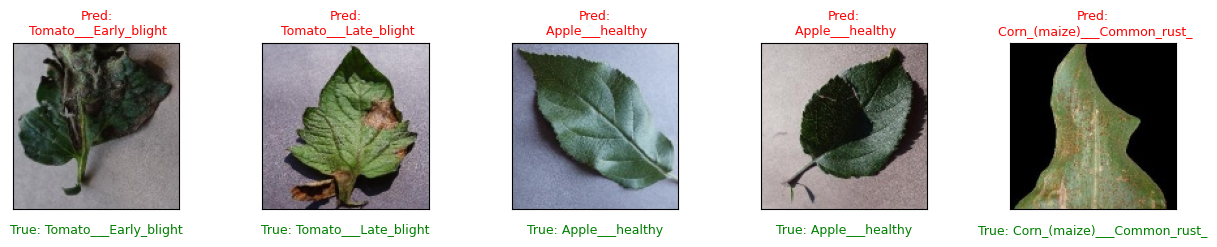

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get class labels (mapping indices to class names)
class_labels = list(train_generator.class_indices.keys())

# Pick a batch of images from the test generator
test_images, test_labels = next(test_generator)  # Get a batch

# Make predictions
predictions = model.predict(test_images)

# Get predicted classes
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)  # True class indices

# Plot the first 5 images with predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 6))  # Increased figure width

for i, ax in enumerate(axes):
    ax.imshow(test_images[i])  # Image is already normalized (0-1 range)
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks

    # Display predicted label at the top
    ax.set_title(f"Pred:\n {class_labels[predicted_classes[i]]}", fontsize=9, color='red')

    # Display true label below the image using ax.text()
    ax.text(0.5, -0.15, f"True: {class_labels[true_classes[i]]}",
            fontsize=9, color='green', ha='center', transform=ax.transAxes)

plt.subplots_adjust(wspace=0.5)  # Add spacing between images to prevent overlap
plt.show()


evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━

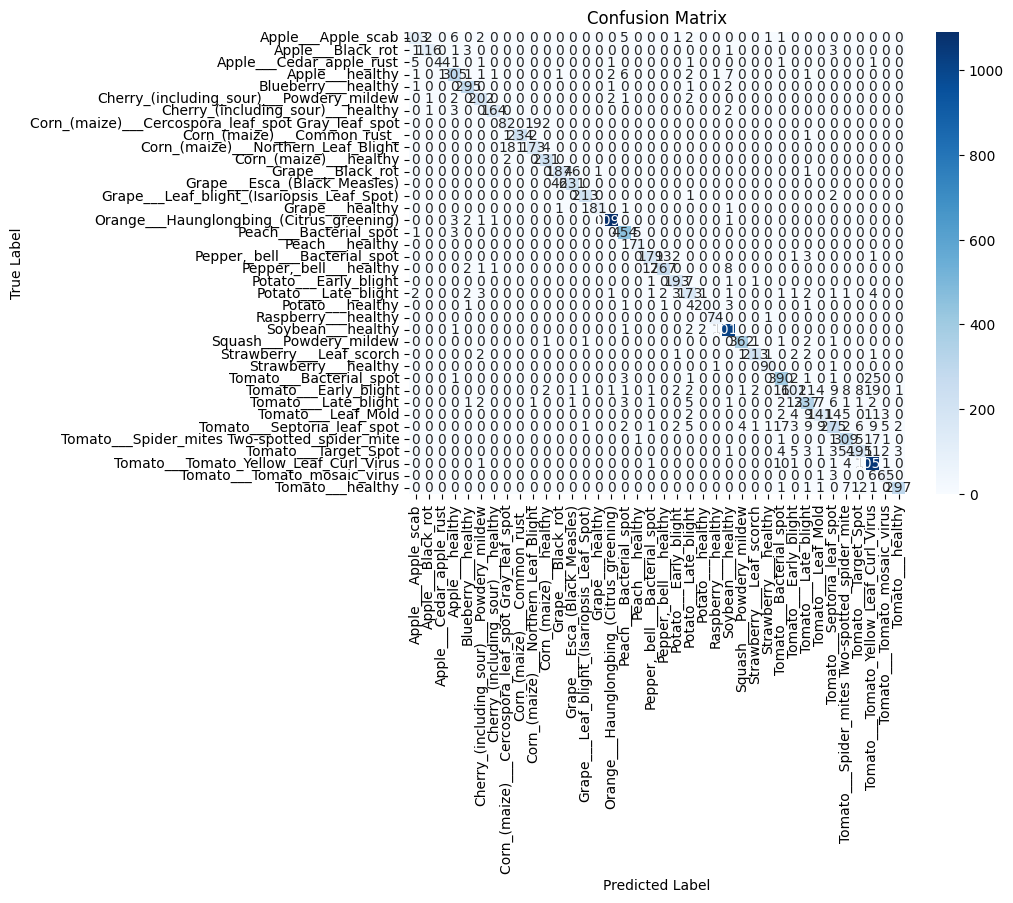

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the saved model
#model = load_model("omni_plant_model.keras")

# Get class labels (mapping indices to class names)
class_labels = list(train_generator.class_indices.keys())

# Predict on the entire test dataset
y_true = []
y_pred = []

# Loop through test_generator to get all images and labels
for images, labels in test_generator:
    predictions = model.predict(images)

    # Convert one-hot encoded labels to class indices
    true_classes = np.argmax(labels, axis=1)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)

    # Stop once all test images are processed
    if len(y_true) >= test_generator.samples:
        break

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Compute F1-score, Recall, and Precision
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


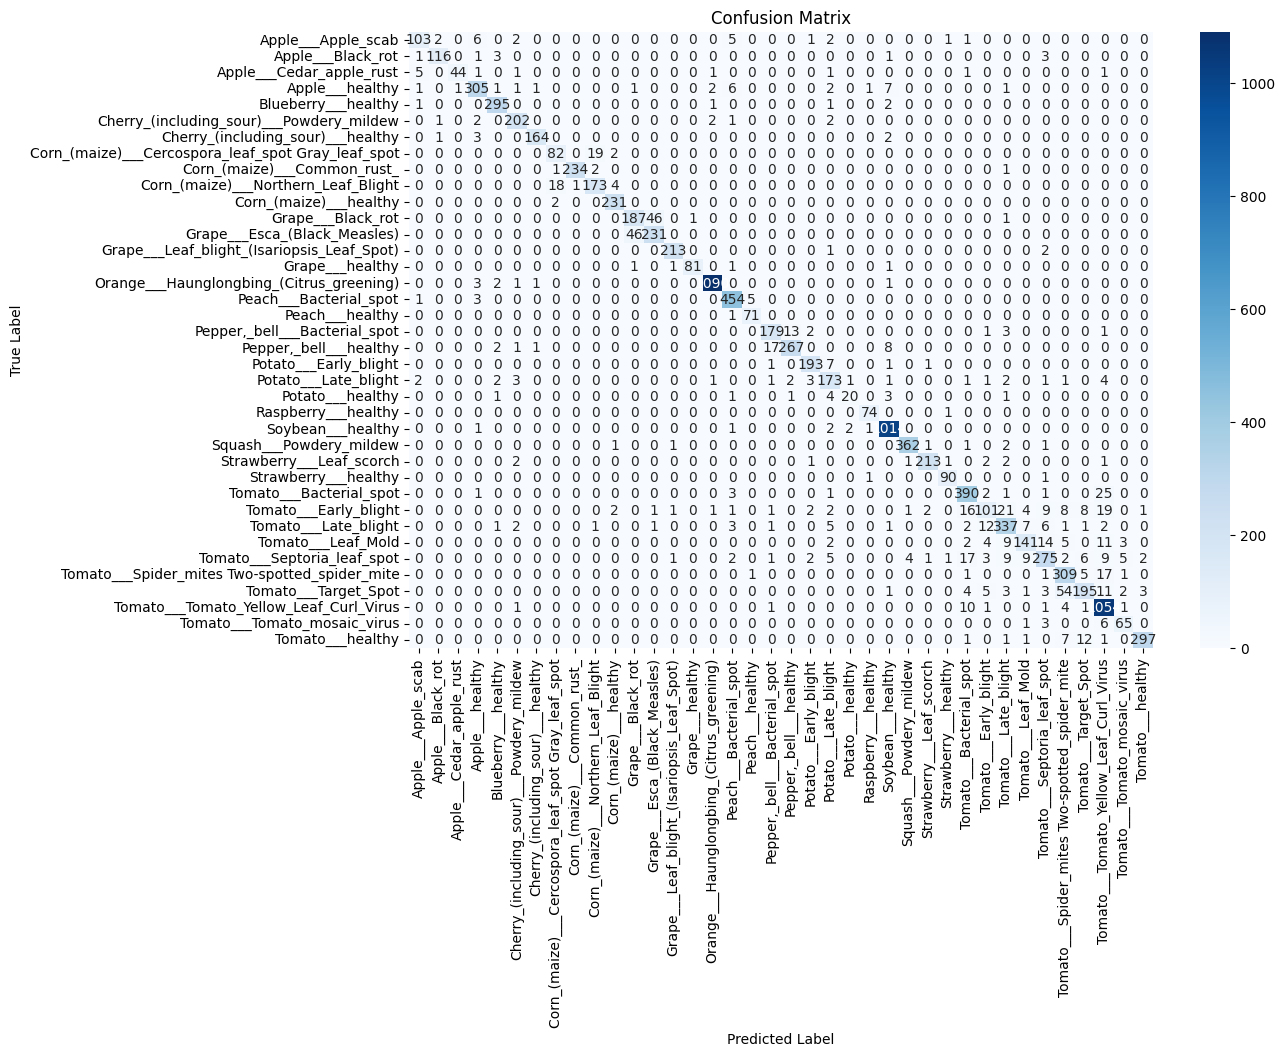

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


#EfficientnetBO

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

I used the pretrained model as base model then customize it according to the dataset I used for this project by adding custom layer on top of the base model so that model can be effective to plantvillage dataset.

In [ ]:
#  Load the EfficientNetB0 model without the top layers (exclude top for custom head)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

#  Freeze the base model layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(38, activation='softmax')(x)  # 38 classes for plant diseases

# Define the model with inputs from the base model and outputs from the custom layers
model = Model(inputs=base_model.input, outputs=predictions)

#  Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Paths for the dataset
train_path = "/content/plantvillage dataset/train"
test_path = "/content/plantvillage dataset/test"

# Flow images from directories for training and validation
train_generator = train_datagen.flow_from_directory(
    train_path,  # Path to your training data
    target_size=(224, 224),  # Resize images to match input size of EfficientNetB0
    batch_size=32,
    class_mode='categorical',  # Multi-class classification
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,  # Path to your test data
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # No need to shuffle validation data
)

# Step 6: Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,  # Adjust epochs as needed
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size
)

Found 43429 images belonging to 38 classes.
Found 10876 images belonging to 38 classes.
Epoch 1/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 568s 400ms/step - accuracy: 0.0973 - loss: 3.3810 - val_accuracy: 0.0938 - val_loss: 3.3516
Epoch 2/10
   1/1357 ━━━━━━━━━━━━━━━━━━━━ 47s 35ms/step - accuracy: 0.0938 - loss: 3.3834

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.0938 - loss: 3.3834 - val_accuracy: 0.0938 - val_loss: 3.3515
Epoch 3/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 534s 394ms/step - accuracy: 0.0999 - loss: 3.3511 - val_accuracy: 0.1016 - val_loss: 3.3485
Epoch 4/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.1562 - loss: 3.4544 - val_accuracy: 0.1016 - val_loss: 3.3483
Epoch 5/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 561s 406ms/step - accuracy: 0.1005 - loss: 3.3477 - val_accuracy: 0.1016 - val_loss: 3.3523
Epoch 6/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0938 - loss: 3.4921 - val_accuracy: 0.1016 - val_loss: 3.3514
Epoch 7/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 623s 419ms/step - accuracy: 0.0985 - loss: 3.3476 - val_accuracy: 0.1016 - val_loss: 3.3483
Epoch 8/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.1562 - loss: 3.2050 - val_accuracy: 0.1016 - val_loss: 3.3483
Epoch 9/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 570s 391ms/step - accuracy: 0.1005 - lo

To improve the performance of the model, fine-tuning is used.

In [ ]:
# Unfreeze the base model layers for fine-tuning
for layer in base_model.layers:
    layer.trainable = True

# Recompile the model after unfreezing layers
model.compile(optimizer=Adam(learning_rate=1e-5),  # Lower learning rate for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Continue training after fine-tuning
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,  # Fine-tune for more epochs
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size
)

Epoch 1/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 690s 452ms/step - accuracy: 0.3590 - loss: 2.6693 - val_accuracy: 0.7451 - val_loss: 1.0866
Epoch 2/10
   1/1357 ━━━━━━━━━━━━━━━━━━━━ 3:02 134ms/step - accuracy: 0.9375 - loss: 0.6052

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9375 - loss: 0.6052 - val_accuracy: 0.7396 - val_loss: 1.1031
Epoch 3/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 576s 424ms/step - accuracy: 0.8505 - loss: 0.6098 - val_accuracy: 0.7870 - val_loss: 0.7374
Epoch 4/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9688 - loss: 0.2067 - val_accuracy: 0.7856 - val_loss: 0.7459
Epoch 5/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 611s 427ms/step - accuracy: 0.9235 - loss: 0.2749 - val_accuracy: 0.8041 - val_loss: 0.6480
Epoch 6/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9375 - loss: 0.1205 - val_accuracy: 0.8002 - val_loss: 0.6637
Epoch 7/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 622s 439ms/step - accuracy: 0.9487 - loss: 0.1785 - val_accuracy: 0.9366 - val_loss: 0.2020
Epoch 8/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9062 - loss: 0.3052 - val_accuracy: 0.9329 - val_loss: 0.2157
Epoch 9/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 624s 460ms/step - accuracy: 0.9614 - lo

In [ ]:
# Step 8: Evaluate the model on the validation set
loss, accuracy = model.evaluate(test_generator)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9546 - loss: 0.1447
Validation Loss: 0.18528510630130768
Validation Accuracy: 0.9417065382003784


In [ ]:
# Save the model
model.save('/content/drive/My Drive/Colab Notebooks/efficient_model.keras')
print("Model saved successfully!")

Model saved successfully!


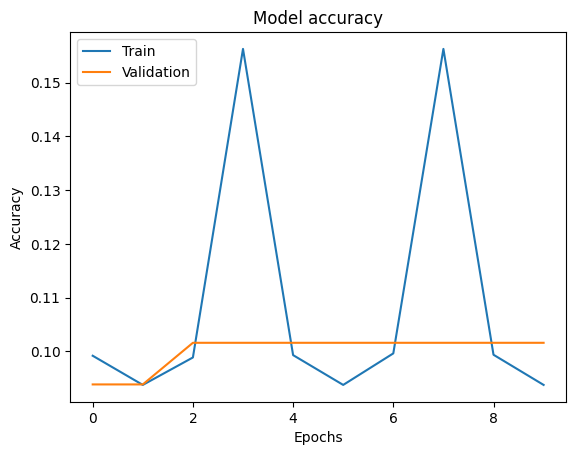

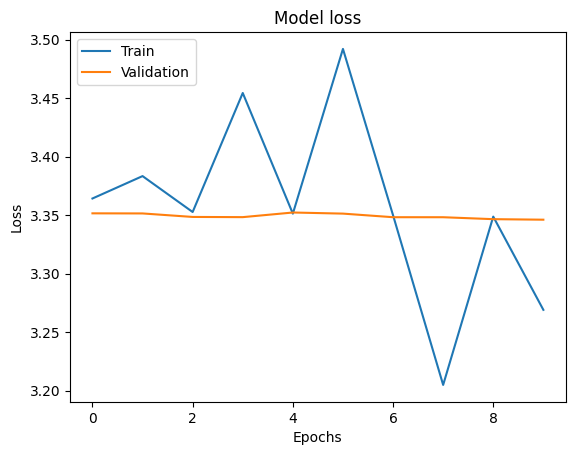

In [ ]:
# Step 9: Plot Training and Validation Accuracy and Loss
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get true labels and predicted labels
# Predict on validation data
test_generator.reset()
pred_probs = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class label names
class_labels = list(test_generator.class_indices.keys())


340/340 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step


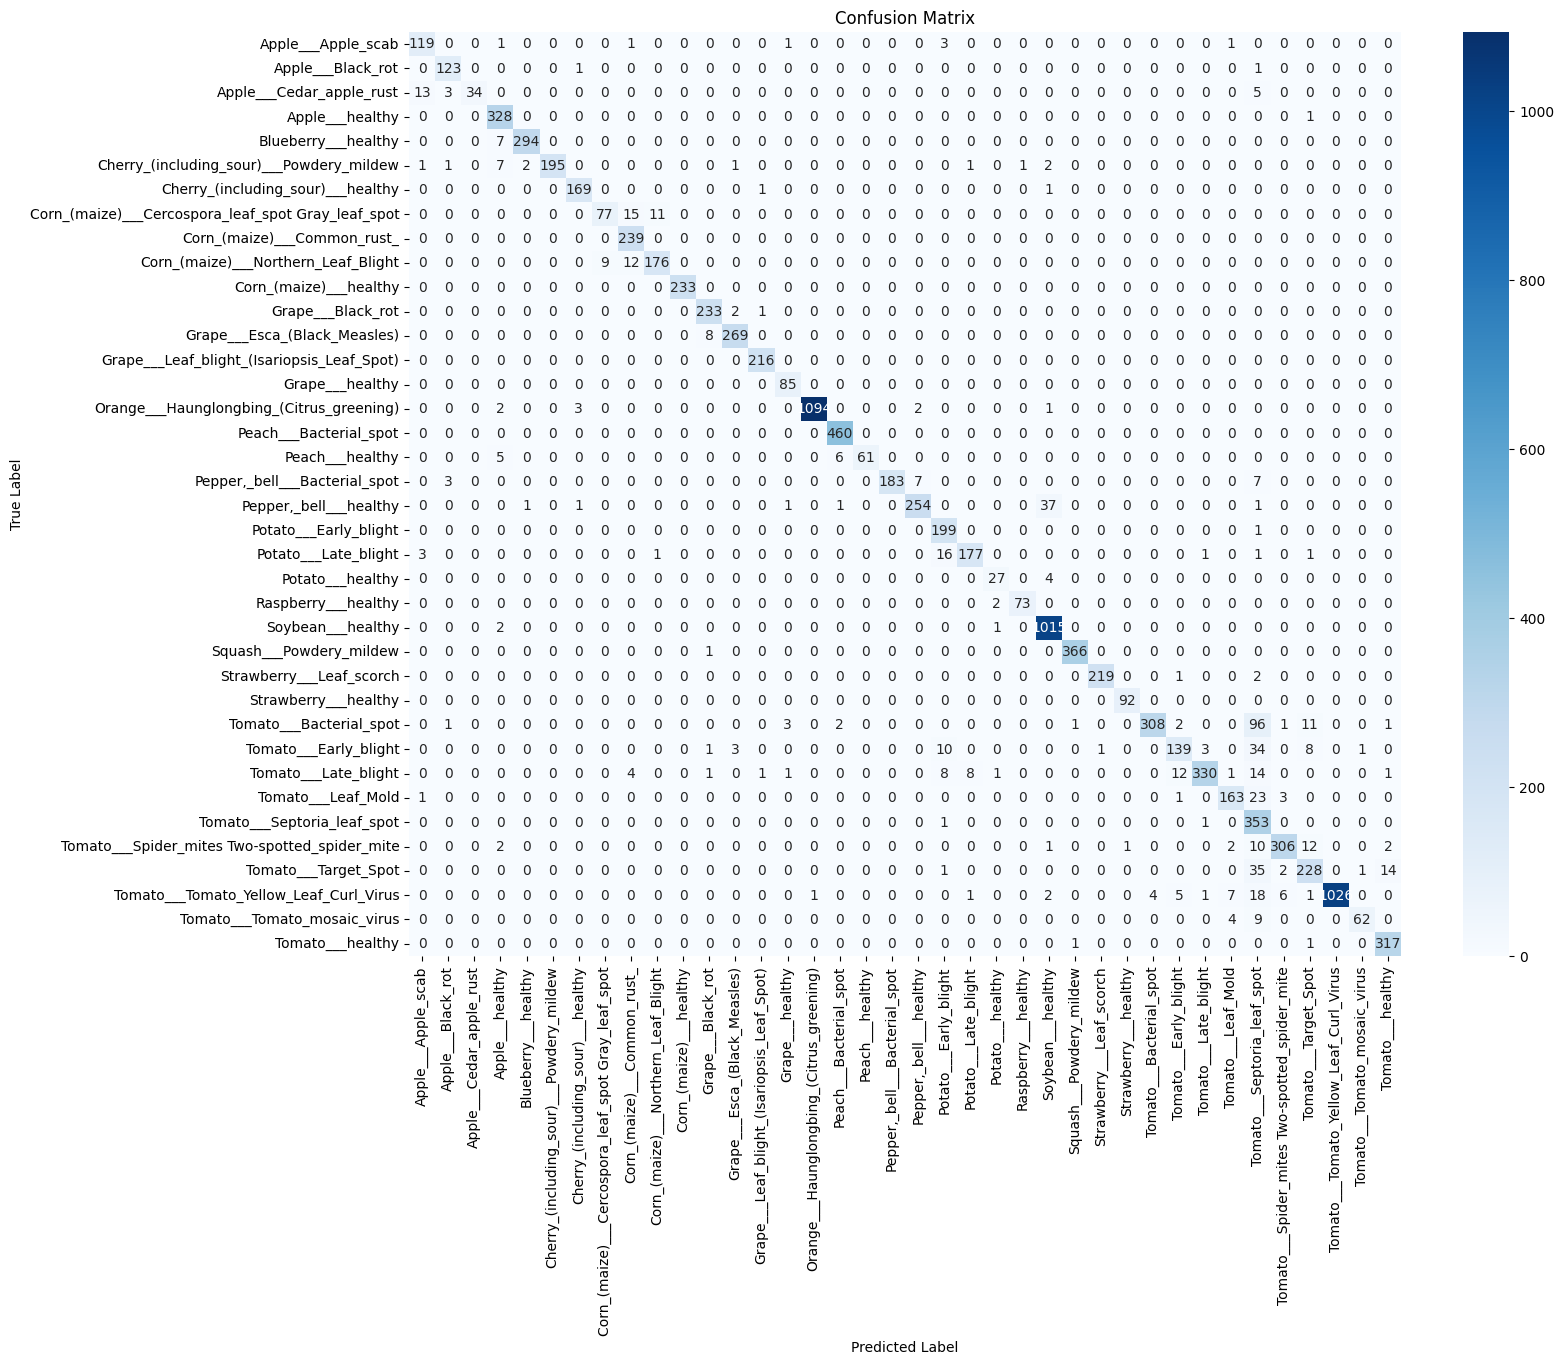

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.87      0.94      0.90       126
                                 Apple___Black_rot       0.94      0.98      0.96       125
                          Apple___Cedar_apple_rust       1.00      0.62      0.76        55
                                   Apple___healthy       0.93      1.00      0.96       329
                               Blueberry___healthy       0.99      0.98      0.98       301
          Cherry_(including_sour)___Powdery_mildew       1.00      0.92      0.96       211
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.75      0.81       103
                       Corn_(maize)___Common_rust_       0.88      1.00      0.94       239
               Corn_(maize)___Northern_Leaf_Blight     

In [ ]:
f1 = f1_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')

print(f"Macro F1 Score: {f1:.4f}")
print(f"Macro Precision Score: {precision:.4f}")


Macro F1 Score: 0.9273
Macro Precision Score: 0.9437


load the model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Load the trained model
model = tf.keras.models.load_model('/content/drive/My Drive/Colab Notebooks/efficient_model.keras', compile=False)

# Recompile the model if necessary (optional)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


I converted the saved efficientnetbo model to tensorflow lite version so, that i can use this in deployment as biggersize of the model was creating difficulties while deploying

In [ ]:
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open('/content/drive/My Drive/Colab Notebooks/efficient_model.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpqzj3qsu8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  135390390803472: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135390390803856: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135393064185936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135393064186704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135393064187664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135393064186512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135393064183824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135393064186896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135390393877328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135390393876560: TensorSpec(shape=(), dtype=tf.resource, name=No

#predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


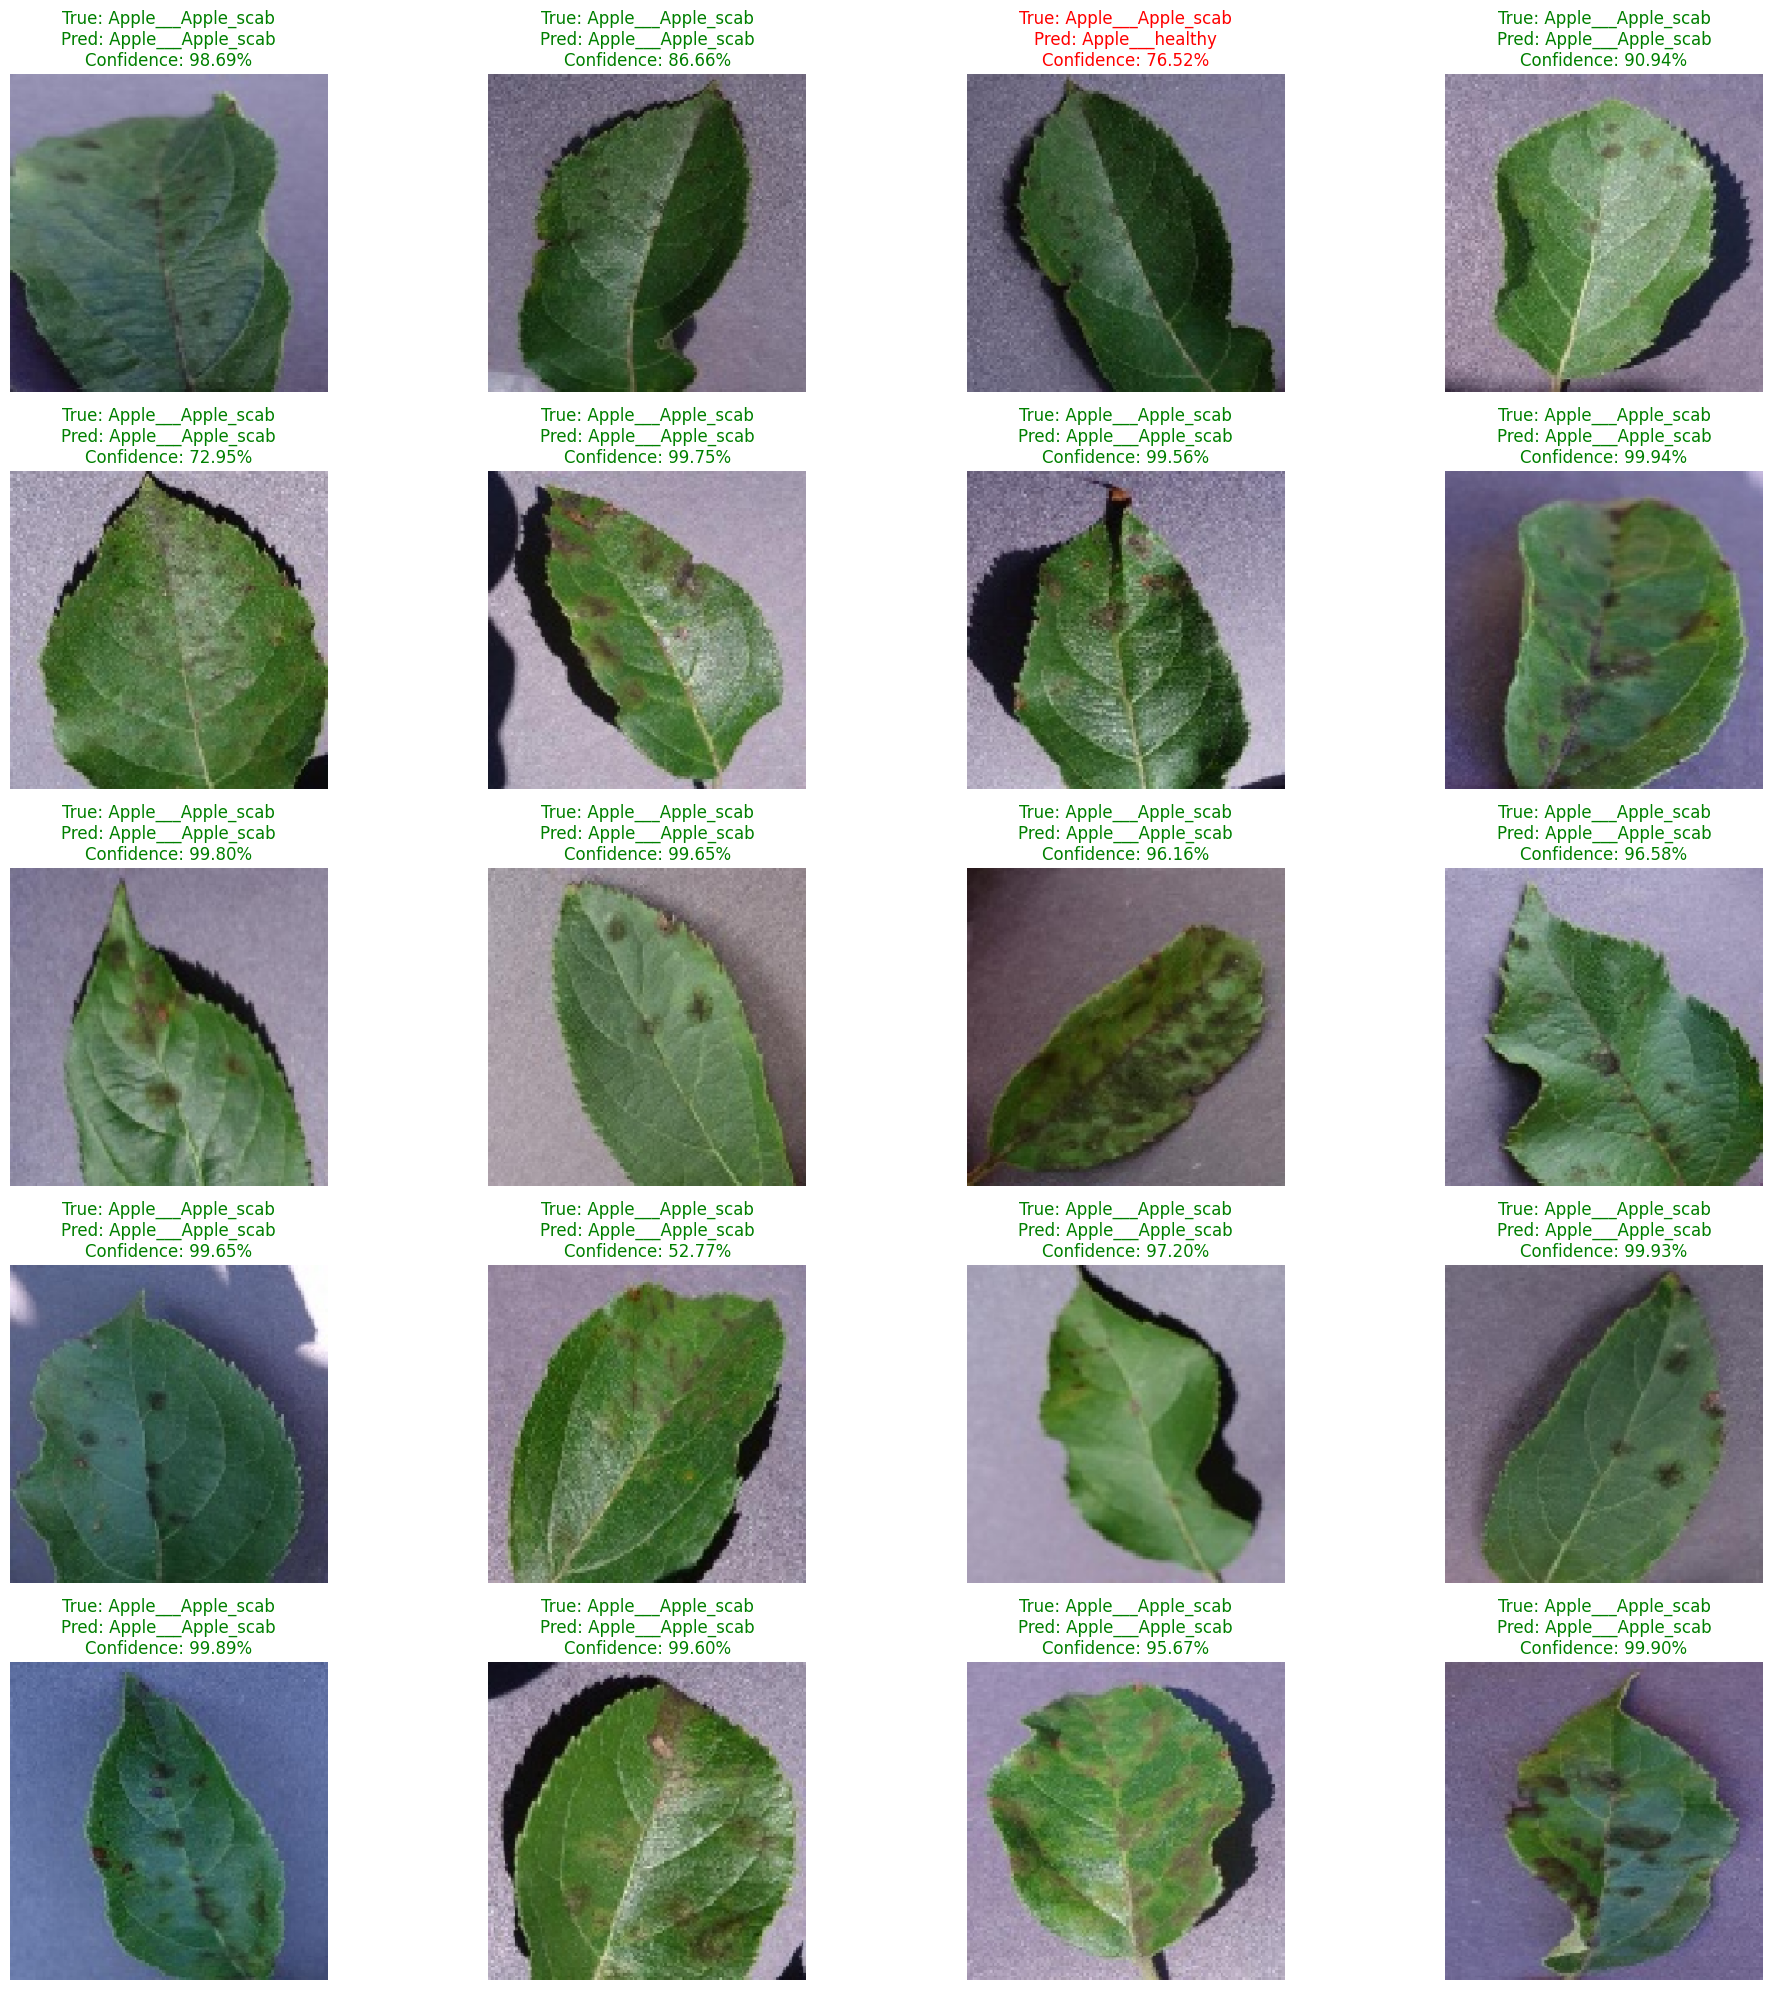

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# Number of images to display
num_images = 20

# Ensure class names list matches predicted indices
class_names = list(train_generator.class_indices.keys())
filenames = test_generator.filenames
true_classes = test_generator.classes

# Create a plot
plt.figure(figsize=(20, 20))

for i in range(num_images):
    img_path = os.path.join(test_generator.directory, filenames[i])
    img = image.load_img(img_path, target_size=(224, 224))

    # Preprocess image for prediction
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Get prediction and confidence
    pred = model.predict(img_array)
    pred_idx = np.argmax(pred)
    confidence = pred[0][pred_idx] * 100  # as percentage

    true_label = class_names[true_classes[i]]
    pred_label = class_names[pred_idx]

    # Plot image
    plt.subplot(5, 4, i + 1)
    plt.imshow(img)
    title_color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConfidence: {confidence:.2f}%", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()


Above is the predicted diseases from the test dataset by efficientnetbo model with the confidence score.